# Airbnb NYC 2019: Data Analysis and Price Prediction
---
## Overview

The Airbnb NYC 2019 Data Analysis and Price Prediction project explores Airbnb listings across New York City to understand pricing, room types, neighbourhoods, availability, reviews, and host activity.

The project uses data cleaning, exploratory data analysis, visualization, and machine learning to identify important patterns and predict Airbnb listing prices. Several regression models are compared to determine which provides the best prediction performance.

## Objectives

How do Airbnb prices vary across neighbourhoods and room types?   
Which neighbourhoods have the most Airbnb listings?  
How do reviews and availability vary across listings?  

How accurately can Airbnb prices be predicted?  
Which machine learning model provides the best price predictions?  

## 1. Installing and Importing Required Libraries

Importing Python libraries for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [1]:
!pip install xgboost
!pip install shap

In [2]:
# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBClassifier, plot_importance
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

## 2. Loading the Airbnb Dataset

The Airbnb NYC 2019 dataset was loaded into a Pandas DataFrame and displays the first few records to understand its structure.

In [3]:
# Load dataset
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Inspecting Dataset Structure and Data Types

This step examines the dataset dimensions, columns, data types, and non-null values to identify potential data-quality issues.

In [4]:
# Inspect data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

## 4. Checking for Duplicate Records

This step checks whether duplicate rows exist so repeated observations do not affect the analysis.

In [5]:
# Check duplicate
df.duplicated().sum()

np.int64(0)

## 5. Identifying Missing Values

This step identifies missing values in each column so appropriate cleaning strategies can be applied.

In [6]:
# Check the missing values
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## 6. Handling Missing Values

Missing values are addressed using suitable replacement strategies. Text fields are assigned an `Unknown` value and missing review-frequency values are treated as zero.

In [7]:
# Addressing the missing values
df["name"].fillna("Unknown", inplace = True)
df["host_name"].fillna("Unknown", inplace = True)
df["reviews_per_month"].fillna(0, inplace = True)

In [8]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## 7. Removing an Unused Date Column

The `last_review` column is removed because it is not used in the current analysis and machine-learning feature set.

In [9]:
# remove last_review column
df.drop("last_review", axis=1, inplace = True)
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365


## 8. Descriptive Statistics

This step summarizes the numerical variables to understand their central tendency, spread, and range.

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,48895.0,1.090910e+00,1.597283e+00,0.00000,4.000000e-02,3.700000e-01,1.580000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


## 9. Detecting Price Outliers

A boxplot is used to identify extreme Airbnb prices that may strongly influence statistical analysis and machine-learning results.

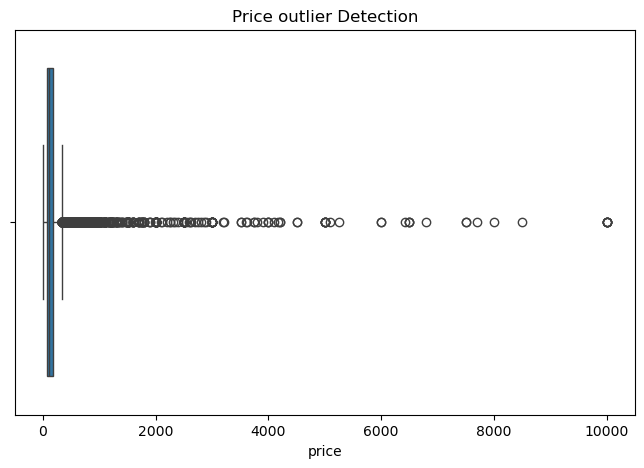

In [11]:
# detection of outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x = "price", data = df)
plt.title("Price outlier Detection")
plt.show()

## 10. Defining the IQR Outlier Method

This cell defines a reusable Interquartile Range (IQR) method for identifying lower and upper outlier boundaries.

In [12]:
# Function to address outlier
def iqr_method(column):
    Q1 = np.percentile(column, 25)
    Q3 = np.percentile(column, 75)
    IQR = Q3 - Q1
    lower_range = Q1 - (1.5 * IQR)
    upper_range = Q3 + (1.5 * IQR)
    
    return lower_range, upper_range

## 11. Removing Extreme Price Outliers

The IQR boundaries are applied to the `price` variable to reduce the influence of extreme price observations.

In [13]:
lower_bound, upper_bound = iqr_method(df["price"])

df = df[(df.price >= lower_bound) & (df.price <= upper_bound)]

## 12. Verifying Price Outlier Treatment

A second boxplot is used to examine the price distribution after the IQR-based outlier treatment.

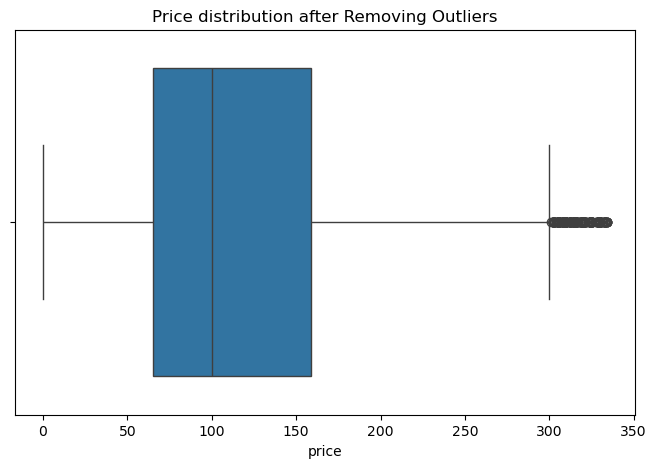

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x = "price", data = df)
plt.title("Price distribution after Removing Outliers")
plt.show()

## 13. Inspecting Availability Outliers

A boxplot is used to examine extreme values in `availability_365`.

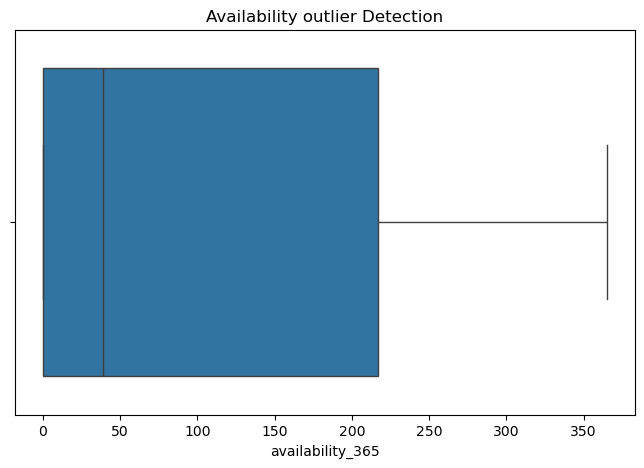

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x = "availability_365", data = df)
plt.title("Availability outlier Detection")
plt.show()

## 14. Inspecting Review-Count Outliers

A boxplot is used to examine the distribution and potential extreme values of `number_of_reviews`.

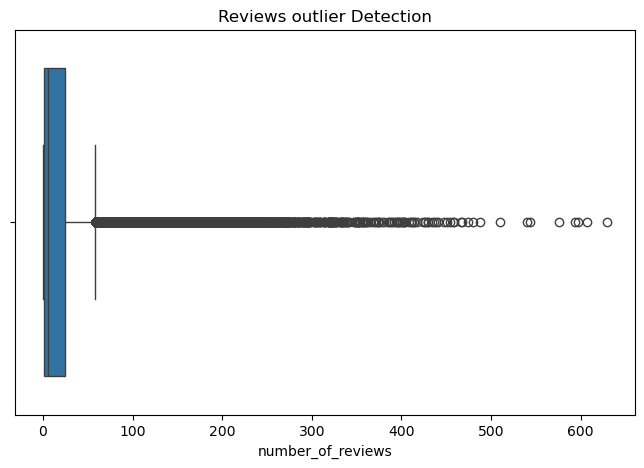

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x = "number_of_reviews", data = df)
plt.title("Reviews outlier Detection")
plt.show()

## 15. Data Visualization

Several visualizations were created to explore patterns in the data before building the final dashboard. These charts helped show comparisons, distributions, and correlation between important metrics.

## 15.1. Distribution of Airbnb Prices

This visualization shows how Airbnb prices are distributed after the price outlier treatment.

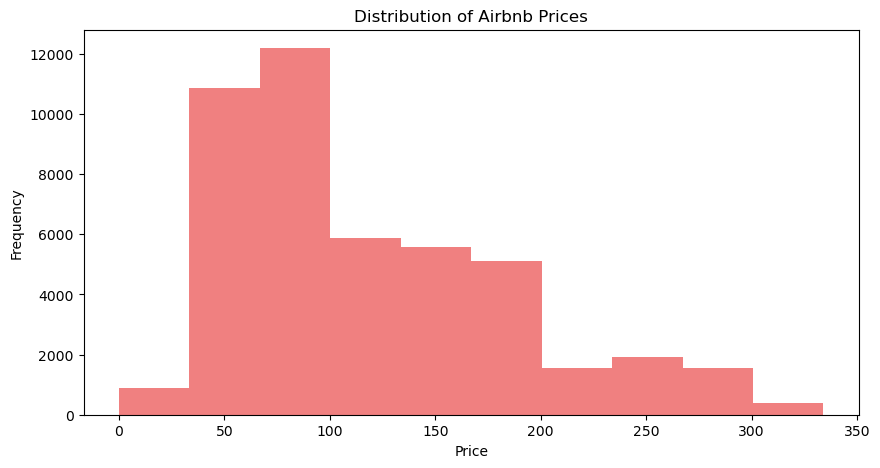

In [17]:
plt.figure(figsize=(10, 5))

plt.hist(df["price"], color= "lightcoral")
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## 15.2 Listing Counts by Neighbourhood Group

This step calculates the number of Airbnb listings in each neighbourhood group.

In [18]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        19506
Brooklyn         19415
Queens            5567
Bronx             1070
Staten Island      365
Name: count, dtype: int64

## 15.3 Visualizing Listings by Neighbourhood Group

This bar chart compares the number of Airbnb listings across neighbourhood groups.

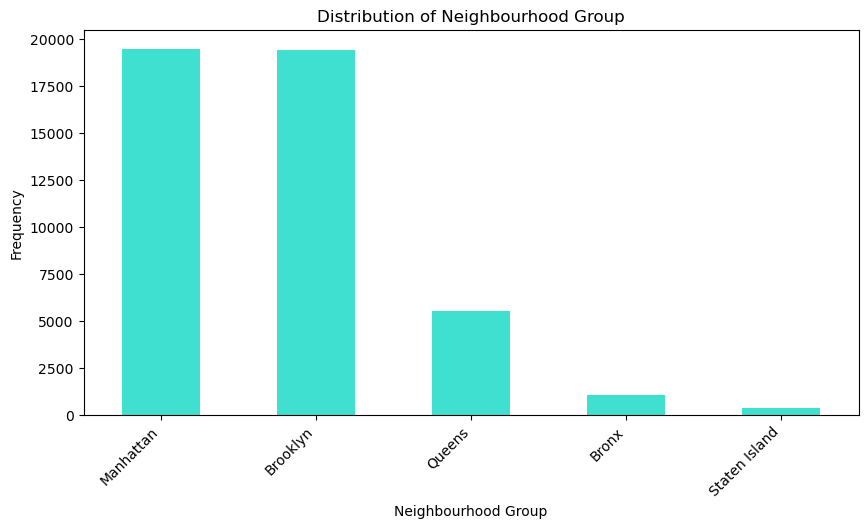

In [19]:
plt.figure(figsize=(10, 5))

df["neighbourhood_group"].value_counts().plot(kind= "bar", color= "turquoise")
plt.title("Distribution of Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Frequency")
plt.xticks(rotation= 45, ha= "right")
plt.show()

## 15.4. Listing Counts by Room Type

This step calculates how many listings belong to each Airbnb room type.

In [20]:
df["room_type"].value_counts()

room_type
Entire home/apt    22789
Private room       21996
Shared room         1138
Name: count, dtype: int64

## 15.5. Room Type Distribution

This pie chart shows the proportion of listings represented by each room type.

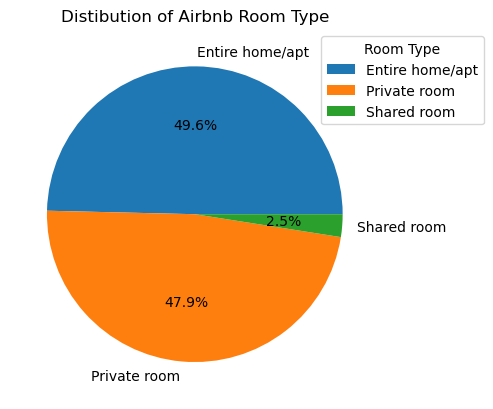

In [21]:
room_type_count = df["room_type"].value_counts()
size = room_type_count.values
label = room_type_count.index

plt.pie(size, labels= label, autopct = "%1.1f%%")
plt.title("Distibution of Airbnb Room Type")
plt.legend(title= 'Room Type', bbox_to_anchor=(0.8, 0, 0.5, 1))
plt.show()

## 15.6. Distribution of Availability

This histogram examines how many days Airbnb listings are available during a 365-day period.

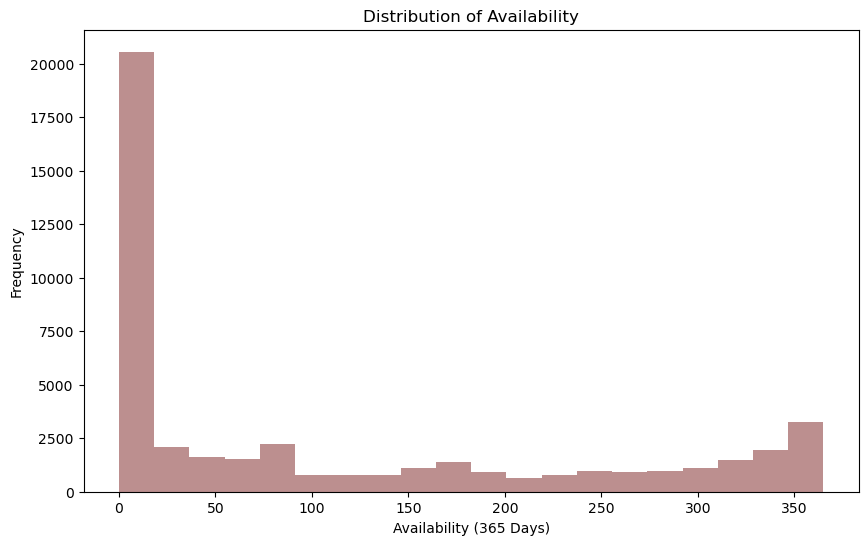

In [22]:
plt.figure(figsize=(10, 6))

plt.hist(df["availability_365"], bins=20, color = 'rosybrown')
plt.xlabel("Availability (365 Days)")
plt.ylabel("Frequency")
plt.title("Distribution of Availability")
plt.show()

## 15.7. Average Price by Neighbourhood Group

This calculation compares average Airbnb prices across neighbourhood groups.

In [23]:
df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)

neighbourhood_group
Manhattan        145.952835
Brooklyn         105.699614
Staten Island     89.235616
Queens            88.904437
Bronx             77.365421
Name: price, dtype: float64

## 15.8. Visualizing Average Price by Neighbourhood Group

This bar chart makes differences in average Airbnb prices across neighbourhood groups easier to compare.

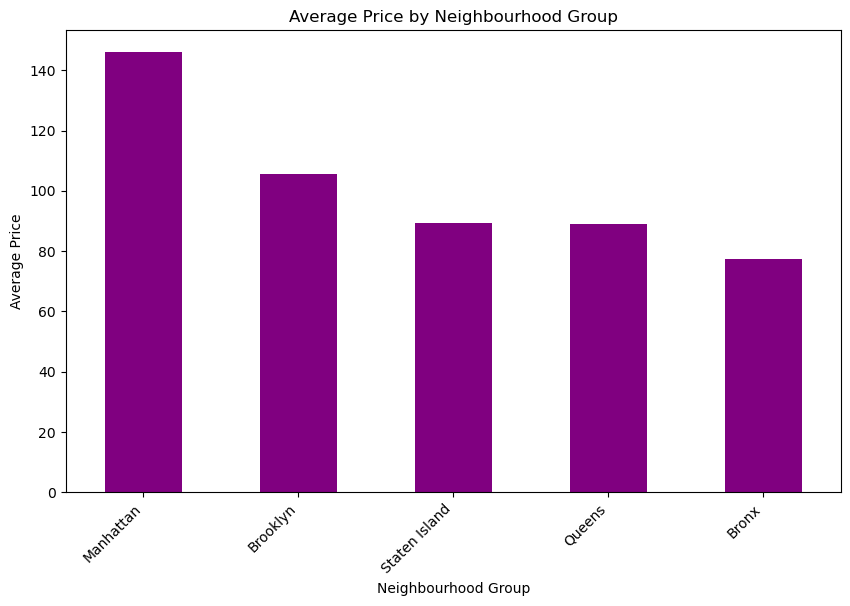

In [24]:
plt.figure(figsize=(10, 6))

df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False).plot(kind="bar", color = "purple")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.title("Average Price by Neighbourhood Group")
plt.xticks(rotation=45, ha = "right")
plt.show()

## 15.9. Average Price by Room Type

This calculation compares the average price of each room type.

In [25]:
df.groupby("room_type")["price"].mean().sort_values(ascending=False)

room_type
Entire home/apt    162.527096
Private room        79.018503
Shared room         59.293497
Name: price, dtype: float64

## 15.10. Price Distribution by Room Type

This boxplot compares price distributions across room types, including their medians and variability.

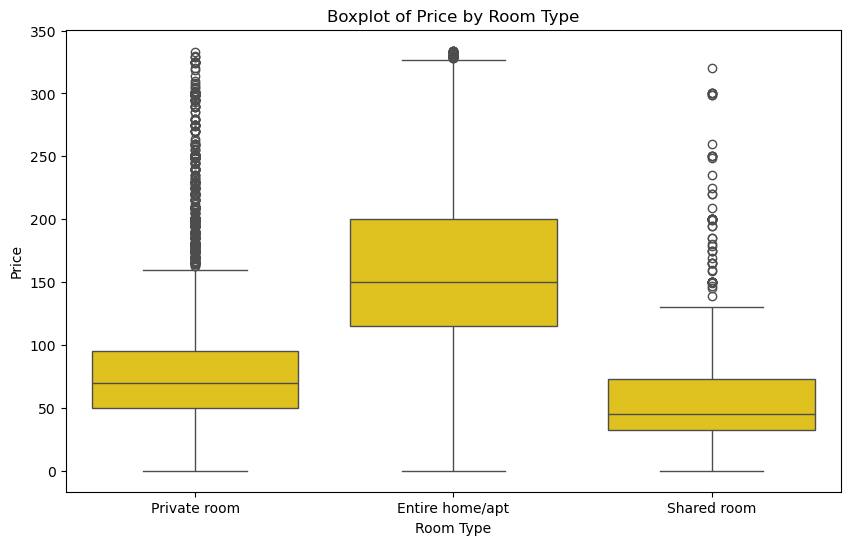

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(x ="room_type", y = "price", data = df, color = "gold")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.title("Boxplot of Price by Room Type")
plt.show()

## 15.11. Relationship Between Price and Number of Reviews

This scatter plot explores whether Airbnb price is associated with the number of reviews received.

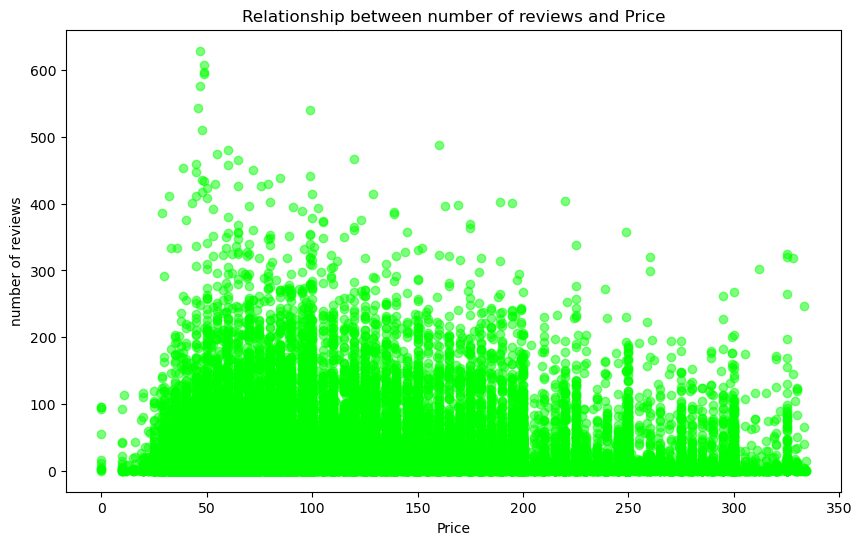

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(df["price"], df["number_of_reviews"], alpha=0.5, color = "lime")
plt.xlabel("Price")
plt.ylabel("number of reviews")
plt.title("Relationship between number of reviews and Price")
plt.show()

## 15.12. Total Reviews by Neighbourhood Group

This calculation identifies which neighbourhood groups have the greatest total review activity.

In [28]:
review_neighbourhood = df.groupby("neighbourhood_group")["number_of_reviews"].sum()
review_neighbourhood

neighbourhood_group
Bronx             28185
Brooklyn         475936
Manhattan        428143
Queens           155719
Staten Island     11536
Name: number_of_reviews, dtype: int64

## 15.13. Review Distribution by Neighbourhood Group

This pie chart visualizes the share of total reviews associated with each neighbourhood group.

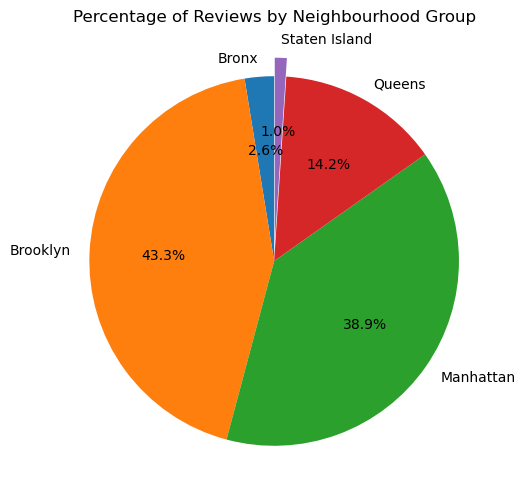

In [29]:
plt.figure(figsize=(10, 6))
explode = [0, 0, 0, 0, 0.1] 
plt.pie(review_neighbourhood, labels=review_neighbourhood.index, autopct="%1.1f%%", startangle=90, explode = explode)
plt.title("Percentage of Reviews by Neighbourhood Group")
plt.show()

## 15.14. Host Activity by Neighbourhood Group

This calculation compares host activity across neighbourhood groups using listing/host records.

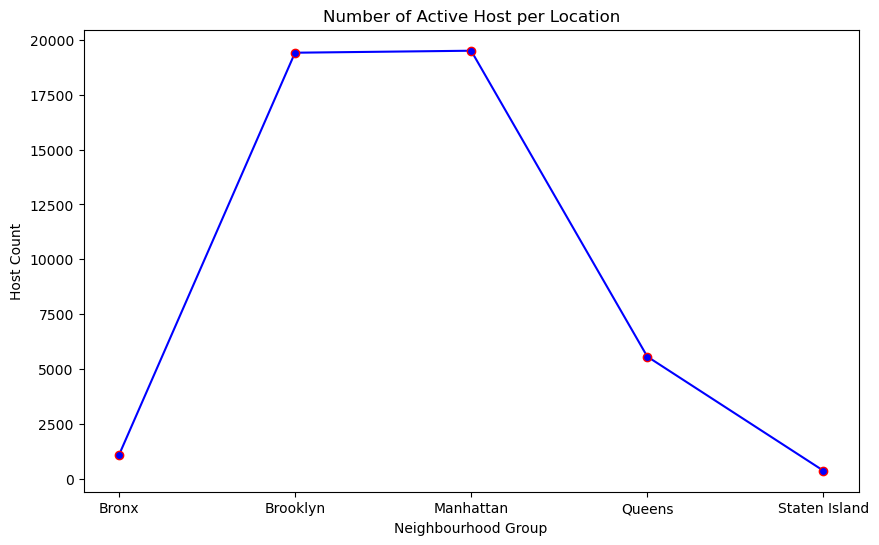

In [30]:
host = df.groupby("neighbourhood_group")["host_id"].count()

host_count = host.values
host_neighbour = host.index

plt.figure(figsize=(10, 6))

plt.plot(host_neighbour, host_count, marker='o', linestyle='-', color='blue', mec = 'r')
plt.xlabel("Neighbourhood Group")
plt.ylabel("Host Count")
plt.title("Number of Active Host per Location")
plt.show()

## 15.15. Top 10 Neighbourhoods by Listing Count

This visualization identifies the neighbourhoods with the highest number of Airbnb listings.

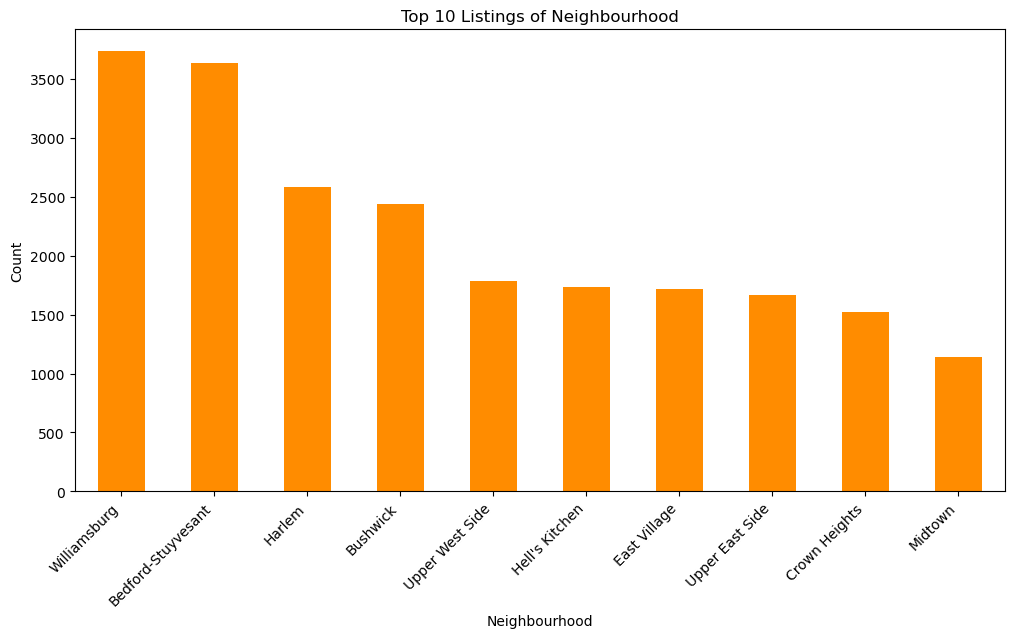

In [31]:
plt.figure(figsize=(12, 6))

df["neighbourhood"].value_counts().head(10).plot(kind="bar", color = "darkorange")
plt.xlabel("Neighbourhood")
plt.ylabel("Count")
plt.title("Top 10 Listings of Neighbourhood")
plt.xticks(rotation=45 , ha = "right")
plt.show()

## 15.16. Geographic Distribution by Neighbourhood Group

This scatter plot uses latitude and longitude to examine the geographic distribution of listings across neighbourhood groups.

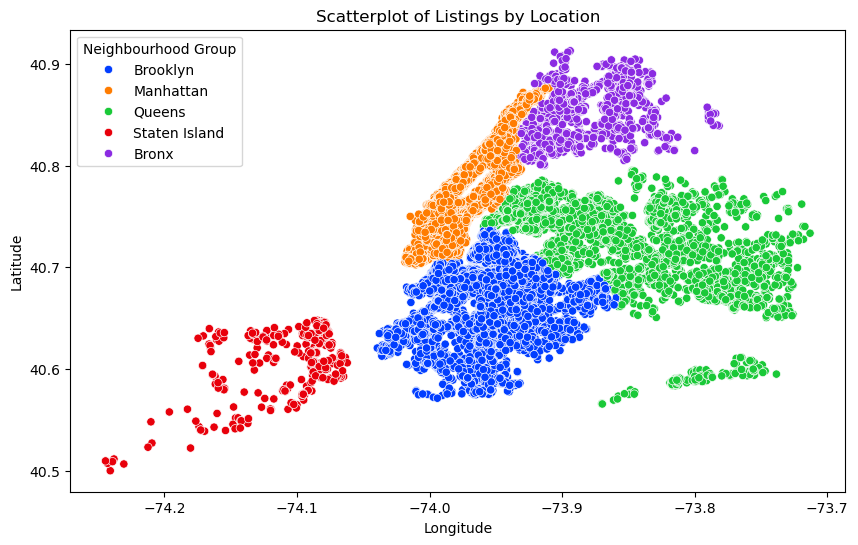

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x = "longitude", y = "latitude", hue = "neighbourhood_group" , data = df, palette = "bright" )
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scatterplot of Listings by Location")
plt.legend(title= "Neighbourhood Group")
plt.show()

## 15.17. Geographic Distribution by Room Type

This visualization examines the geographic distribution of different Airbnb room types.

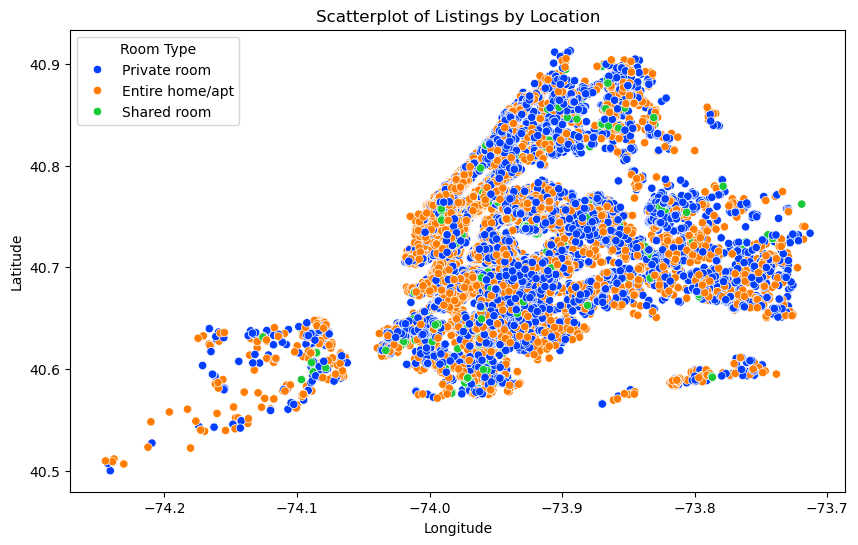

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x = "longitude", y = "latitude", hue = "room_type" , data = df, palette = "bright" )
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scatterplot of Listings by Location")
plt.legend(title= "Room Type")
plt.show()

## 15.18. Correlation Analysis

This correlation matrix examines relationships between price and selected numerical Airbnb features.

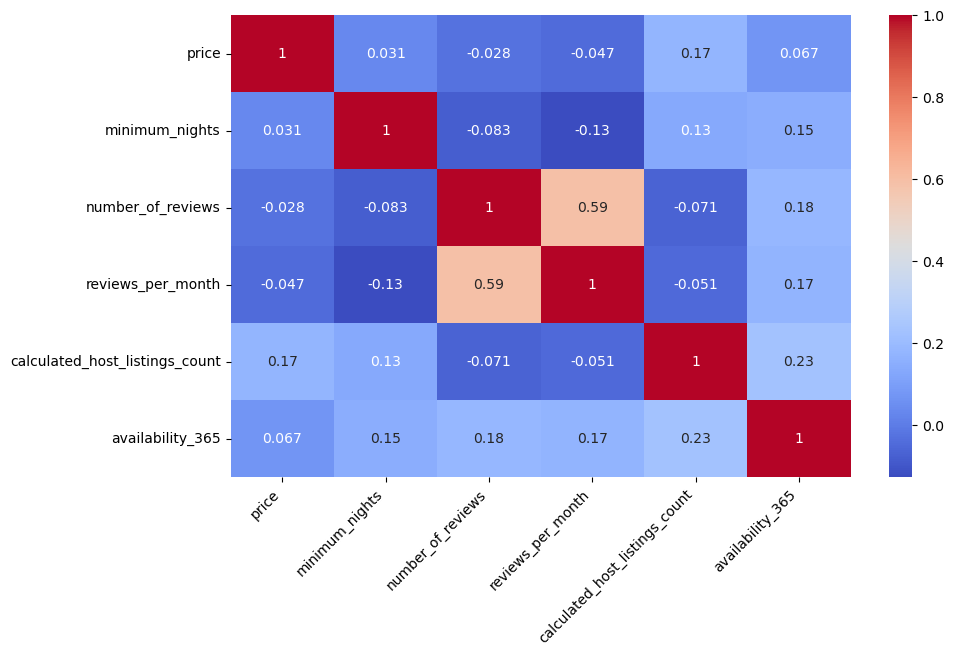

In [34]:
corr_matrix = df[["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.xticks(rotation =45, ha = "right")
plt.show()

## 16. Inspecting Available Features

This step reviews the available dataset columns before selecting variables for machine learning.

In [35]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

# 17. Machine Learning Preparation

The objective of this section is to prepare the cleaned Airbnb data for regression models that predict listing price. Numerical and categorical features are identified so that each can receive appropriate preprocessing.

In [36]:
numerical_col = ['minimum_nights', 'number_of_reviews', 'reviews_per_month','calculated_host_listings_count', 'availability_365']
categorical_col = ['neighbourhood_group', 'room_type']

## 17.1. Selecting Features and Target

The selected numerical and categorical variables are combined into `X`, while `price` is defined as the target variable `y`.

In [37]:
scale = StandardScaler()
X = df[['minimum_nights', 'number_of_reviews', 'reviews_per_month','calculated_host_listings_count', 'availability_365', 'neighbourhood_group', 'room_type']]
y = scale.fit_transform(df[['price']])

## 17.2. Train/Test Split and Preprocessing Pipeline

The data is divided into training and testing sets. A `ColumnTransformer` standardizes numerical features and one-hot encodes categorical features so the same preprocessing can be applied consistently during model training and prediction.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers = [
                                        ('numeric', StandardScaler(), numerical_col),
                                        ('category', OneHotEncoder(handle_unknown='ignore'), categorical_col)],
                                 remainder = 'passthrough')

# 17.3. Linear Regression

Linear Regression provides a baseline regression model for predicting Airbnb prices and assumes a linear relationship between the selected features and the target.

In [39]:
# Linear regression model
model1 = Pipeline(steps = [
                    ('preprocessor', preprocessor),
                    ('linear', LinearRegression())])

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

r_score = r2_score(y_test, y_pred1)
MSE = mean_squared_error(y_test, y_pred1)

print(f"R Squared: {r_score:.2f}")
print(f"Mean Squared Error: {MSE:.2f}")

R Squared: 0.46
Mean Squared Error: 0.54


# 17.4. Decision Tree Regression

Decision Tree Regression is used to capture non-linear relationships between Airbnb characteristics and price. The tree depth is limited to control model complexity.

In [40]:
# Decision tree model
model2 = Pipeline(steps = [
                    ('preprocessor', preprocessor),
                    ('linear', DecisionTreeRegressor(max_depth=5, random_state = 42))])

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

r_score = r2_score(y_test, y_pred2)
MSE = mean_squared_error(y_test, y_pred2)

print(f"R Squared: {r_score:.2f}")
print(f"Mean Squared Error: {MSE:.2f}")

R Squared: 0.47
Mean Squared Error: 0.53


# 17.5. Random Forest Regression

Random Forest combines multiple decision trees to model more complex relationships and improve predictive performance compared with a single tree.

In [41]:
# Random forest model
model3 = Pipeline(steps = [
                    ('preprocessor', preprocessor),
                    ('linear', RandomForestRegressor(max_depth=5, random_state = 42))])

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

r_score = r2_score(y_test, y_pred3)
MSE = mean_squared_error(y_test, y_pred3)

print(f"R Squared: {r_score:.2f}")
print(f"Mean Squared Error: {MSE:.2f}")

R Squared: 0.48
Mean Squared Error: 0.52


# 17.6. XGBoost Regression

XGBoost builds boosted decision trees sequentially to capture complex non-linear relationships and reduce prediction errors.

In [42]:
# XGBoost regressor model
model5 = Pipeline(steps = [
                    ('preprocessor', preprocessor),
                    ('xgboost', XGBRegressor(random_state = 42))])

model5.fit(X_train, y_train)

y_pred5 = model5.predict(X_test)

r_score = r2_score(y_test, y_pred5)
MSE = mean_squared_error(y_test, y_pred5)



feature_names = model5.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance
importance = xgb_model.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    by='Importance', 
    ascending=False
)

print(feature_importance)


print(f"R Squared: {r_score:.2f}")
print(f"Mean Squared Error: {MSE:.2f}")
print(importance)

                                        Feature  Importance
10          category__room_type_Entire home/apt    0.696026
7       category__neighbourhood_group_Manhattan    0.179570
6        category__neighbourhood_group_Brooklyn    0.020306
11             category__room_type_Private room    0.019003
3       numeric__calculated_host_listings_count    0.015728
0                       numeric__minimum_nights    0.013857
4                     numeric__availability_365    0.011235
5           category__neighbourhood_group_Bronx    0.010289
2                    numeric__reviews_per_month    0.008350
1                    numeric__number_of_reviews    0.008209
8          category__neighbourhood_group_Queens    0.007291
9   category__neighbourhood_group_Staten Island    0.005631
12              category__room_type_Shared room    0.004506
R Squared: 0.50
Mean Squared Error: 0.50
[0.01385663 0.00820878 0.00834969 0.0157276  0.01123505 0.01028881
 0.02030586 0.17956974 0.00729106 0.00563107 0.69602

# 17.7. Best Parameters

Selecting best paramter for our model using grid search

In [44]:
param_grid = {
    "xgboost__n_estimators": [100, 200],
    "xgboost__max_depth": [3, 6],
    "xgboost__learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    model5,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best R²:", grid.best_score_)

Best Parameters: {'xgboost__learning_rate': 0.05, 'xgboost__max_depth': 6, 'xgboost__n_estimators': 200}
Best R²: 0.5139530692622725


# 17.7. Best Model



In [45]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Best Model R²:", r2_score(y_test, y_pred))
print("Best Model MSE:", mean_squared_error(y_test, y_pred))

Best Model R²: 0.5089751430881262
Best Model MSE: 0.4924966706856061


# 17.8 Feature and Importance

In [52]:
model = best_model.named_steps["xgboost"]

importance = pd.DataFrame({
    "Feature": best_model.named_steps["preprocessor"].get_feature_names_out(),
    "Importance": model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance

,Feature,Importance
10,category__room_type_Entire home/apt,0.783719
7,category__neighbourhood_group_Manhattan,0.149636
6,category__neighbourhood_group_Brooklyn,0.013822
11,category__room_type_Private room,0.009768
3,numeric__calculated_host_listings_count,0.008109
0,numeric__minimum_nights,0.007899
4,numeric__availability_365,0.006601
2,numeric__reviews_per_month,0.004641
1,numeric__number_of_reviews,0.004481
5,category__neighbourhood_group_Bronx,0.004287


# 17.9. Shap Value

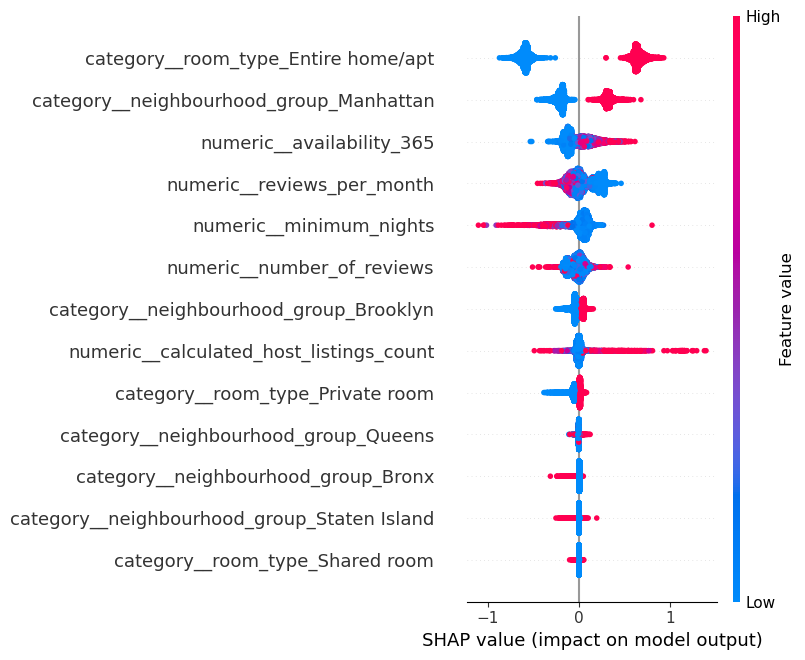

In [49]:
import shap

# Transform the test data
X_test_transformed = model5.named_steps['preprocessor'].transform(X_test)

# Create SHAP explainer
explainer = shap.TreeExplainer(model5.named_steps['xgboost'])

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)
